In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/retail_store_inventory.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 73100
Columns: 15


In [6]:
df.columns.tolist()

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Weather Condition',
 'Holiday/Promotion',
 'Competitor Pricing',
 'Seasonality']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 11.4 MB


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [10]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [13]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Date : 731
Store ID : 5
Product ID : 20
Category : 5
Region : 4
Inventory Level : 451
Units Sold : 498
Units Ordered : 181
Demand Forecast : 31608
Price : 8999
Discount : 5
Weather Condition : 4
Holiday/Promotion : 2
Competitor Pricing : 9751
Seasonality : 4


In [14]:
numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]

for column in numeric_columns:
    print(
        column,
        "Minimum:", df[column].min(),
        "Maximum:", df[column].max()
    )

Inventory Level Minimum: 50 Maximum: 500
Units Sold Minimum: 0 Maximum: 499
Units Ordered Minimum: 20 Maximum: 200
Demand Forecast Minimum: -9.99 Maximum: 518.55
Price Minimum: 10.0 Maximum: 100.0
Discount Minimum: 0 Maximum: 20
Competitor Pricing Minimum: 5.03 Maximum: 104.94


In [15]:
for column in numeric_columns:
    negative_count = (df[column] < 0).sum()
    print(column, "negative values:", negative_count)

Inventory Level negative values: 0
Units Sold negative values: 0
Units Ordered negative values: 0
Demand Forecast negative values: 673
Price negative values: 0
Discount negative values: 0
Competitor Pricing negative values: 0


In [16]:
target = "Units Sold"

Step 9: Explore demand distributions

Units sold distribution

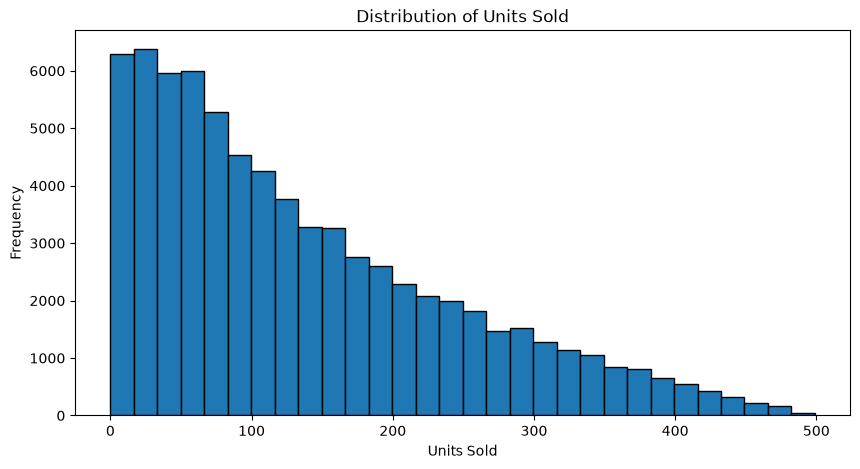

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["Units Sold"], bins=30, edgecolor="black")
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

Average demand by category

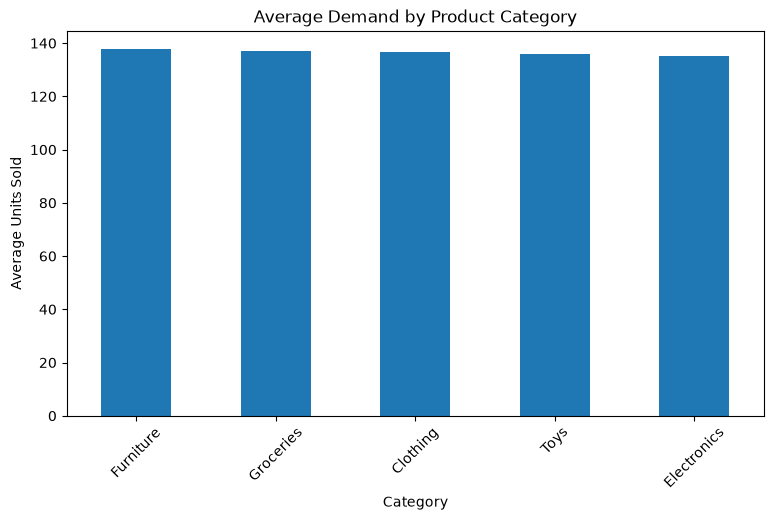

In [18]:
category_demand = (
    df.groupby("Category")["Units Sold"]
    .mean()
    .sort_values(ascending=False)
)

category_demand.plot(kind="bar", figsize=(9, 5))

plt.title("Average Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

Average demand by category

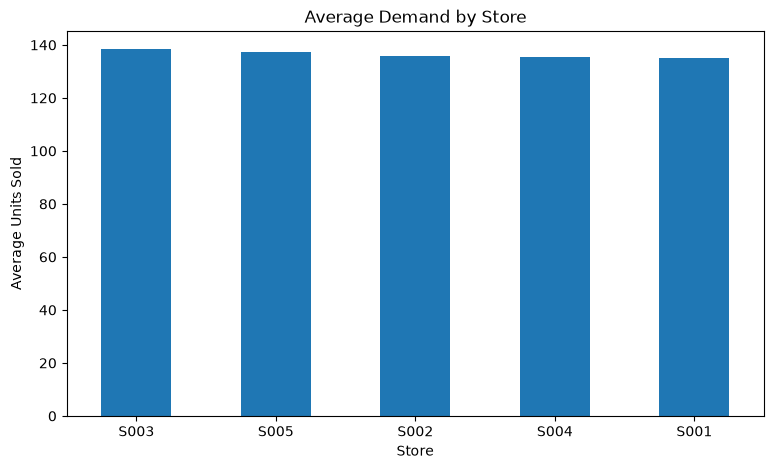

In [19]:
store_demand = (
    df.groupby("Store ID")["Units Sold"]
    .mean()
    .sort_values(ascending=False)
)

store_demand.plot(kind="bar", figsize=(9, 5))

plt.title("Average Demand by Store")
plt.xlabel("Store")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

Demand by season

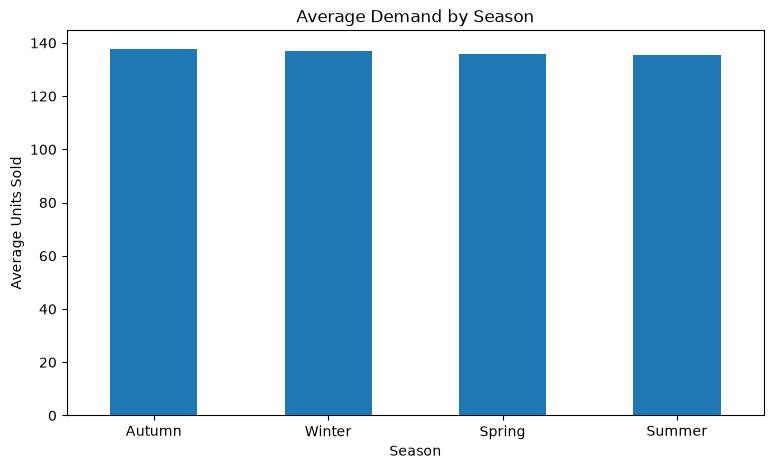

In [20]:
season_demand = (
    df.groupby("Seasonality")["Units Sold"]
    .mean()
    .sort_values(ascending=False)
)

season_demand.plot(kind="bar", figsize=(9, 5))

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

Promotion impact

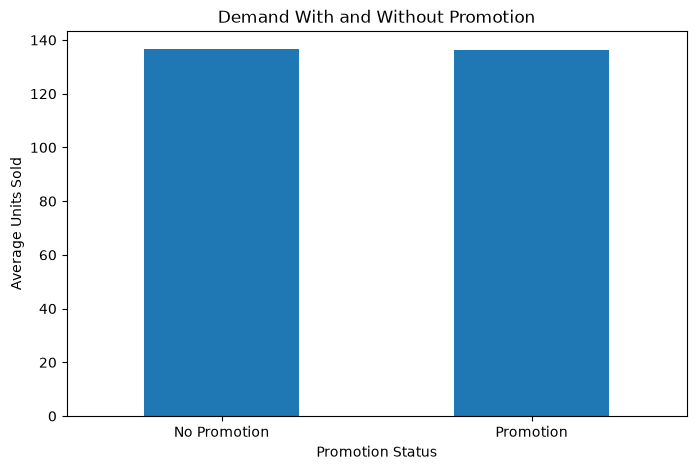

In [21]:
promotion_demand = (
    df.groupby("Holiday/Promotion")["Units Sold"]
    .mean()
)

promotion_demand.index = ["No Promotion", "Promotion"]

promotion_demand.plot(kind="bar", figsize=(8, 5))

plt.title("Demand With and Without Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()


Weather impact

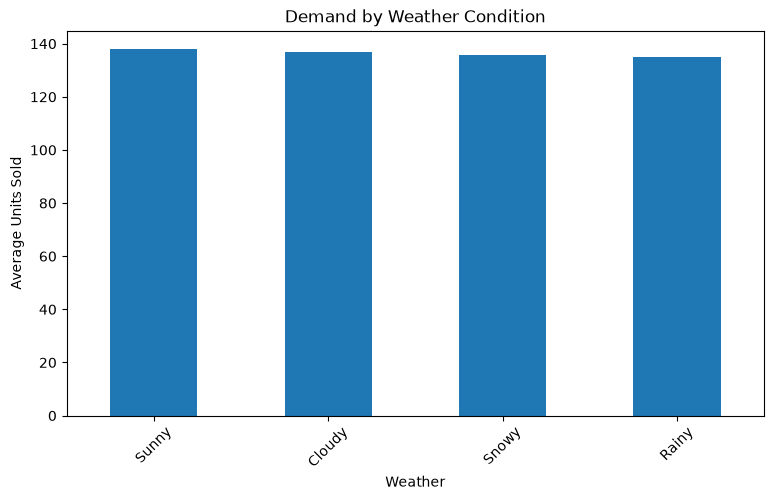

In [22]:
weather_demand = (
    df.groupby("Weather Condition")["Units Sold"]
    .mean()
    .sort_values(ascending=False)
)

weather_demand.plot(kind="bar", figsize=(9, 5))

plt.title("Demand by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

Step 10: Monthly demand trend

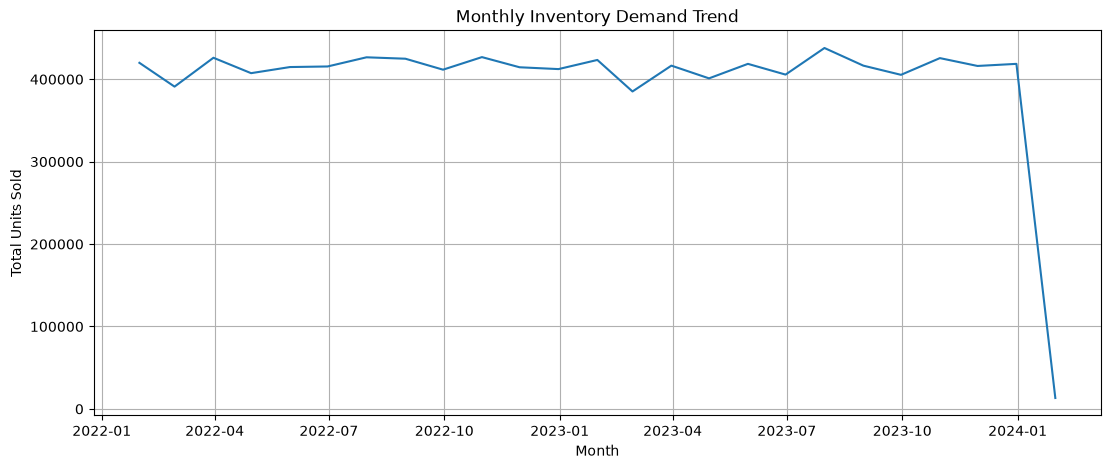

In [23]:
monthly_demand = (
    df.set_index("Date")
    .resample("ME")["Units Sold"]
    .sum()
)

plt.figure(figsize=(13, 5))
plt.plot(monthly_demand.index, monthly_demand.values)

plt.title("Monthly Inventory Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.grid(True)
plt.show()

This chart shows whether total inventory demand rises or falls over time.

Step 11: Feature engineering

In [24]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

In [25]:
df["PriceDifference"] = (
    df["Competitor Pricing"] - df["Price"]
)

df["DiscountedPrice"] = (
    df["Price"] * (1 - df["Discount"] / 100)
)

In [26]:
df["InventoryToSalesRatio"] = (
    df["Inventory Level"] / (df["Units Sold"] + 1)
)

Step 12: Create historical demand features

In [27]:
df = df.sort_values(
    by=["Store ID", "Product ID", "Date"]
)

In [28]:
df["Lag_1"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .shift(1)
)

df["Lag_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .shift(7)
)

df["Lag_14"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .shift(14)
)

df["Lag_30"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .shift(30)
)

In [29]:
df["RollingMean_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(
        lambda series: series.shift(1).rolling(7).mean()
    )
)

df["RollingMean_30"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .transform(
        lambda series: series.shift(1).rolling(30).mean()
    )
)

In [30]:
df = df.dropna().reset_index(drop=True)

In [31]:
df.to_csv(
    "../data/processed_inventory_data.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
